# LAB2 Частина 1. Оцінка параметрів функції

Виконавець:  <b>впишіть власне ПІБ</b>, група <b>впишіть власну групу</b>
<br> Викладач: <b>впишіть хто веде лабораторні заняття</b>

Нам знадобляться бібліотеки <code>numpy</code>, <code>scipy</code>, <code>matplolib</code>.
<br>
Бібліотеки є сторонніми, отже потребують встановлення. Краще у віртуальне оточення. 
<br>
Мали бути встановлені, якщо ні (клітина з імпортуванням виконується з помилкою), то треба встановити. Можна прямо з Jupyter. Тільки не під час пари. Встановлення <code>matplolib</code> вимагатиме часу.

<b>Наступну клітину можна розкоментовувати та виконувати тільки, якщо в якості ядра (kernel) вибране віртуальне оточення!</b>

In [1]:
#!pip install scipy, matplotlib

Якщо встановлювати не в оточення, то хоча б тільки для користувача (з ключем --user).

In [2]:
#!pip3.14 install scipy, matplotlib --user    # Linux

In [3]:
#!py -3.14 -m pip install scipy, matplotlib --user    # Windows

In [1]:
import numpy as np
import scipy, scipy.linalg as la
import matplotlib, matplotlib.pyplot as plt
print(f'numpy {np.__version__}, scipy {scipy.__version__}, matplotlib {matplotlib.__version__}')

numpy 2.4.1, scipy 1.17.0, matplotlib 3.10.8


### Постановка задачі

У результаті кількох експериментів з обчислення швидкодії програми була отримана низка даних вигляду $(n, t)$, де <br> 
$n$ &mdash; розмір оброблюваних вхідних даних, <br>
$t$ &mdash; кількість часу, що була в середньому необхідна для їх обробки.

Дослідник знає, що часова складність програми повинна мати вигляд $T(n)=\Theta(n^a)$.
Знайти значення параметра $a$.

<i>Зауваження</i>. 
Якщо $T(n)=\Theta(n^a)$, то можна вважати, що $T(n)\approx cn^a$.

#### Підготовка даних

Спочатку підготуємо "експериментальні" дані. 
Для цього слід задати значення параметрів <code>c</code> та <code>a</code> та згенерувати "експериментальні" дані в точках також вручну заданої майже логарифмічної шкали <code>n</code>, що містить розміри оброблюваних даних.

В якості шкали використаємо послідовність значень 1, 2, 4, 10, 20, 50, 100, 200, 500, 1000.

Створити змінні <code>c</code>, <code>a</code> зі значеннями $4.5$ та $2.2$ відповідно.

In [5]:
c = запишіть_вираз
a = запишіть_вираз

Створити багатовимірний масив <code>n</code> розмірності 1, який зберігає шкалу значень.

Допоможе функція <code>np.array</code> <a href="https://numpy.org/doc/stable/reference/generated/numpy.array.html#numpy.array" target=_blank 
rel="noopener noreferrer">Документація</a>.

<details>
    <summary>Підказка.</summary> Шкалу у функцію можна передати як кортеж (послідовність значень, записана через кому і взята в круглі дужки; наприклад, (1, 2, 3)).
</details>

In [6]:
n = запишіть_вираз
n

array([   1,    2,    4,   10,   20,   50,  100,  200,  500, 1000])

Далі треба згенерувати результати експериментів. Для цього напишемо функцію <code>T_shifted</code>, що за розміром даних буде повертати кількість часу, схожу на час роботи програми на цих даних. Далі ця функція буде застосовуватись до багатовимірних масивів, тому в ній можна використовувати математичні оператори та математичні функції з бібліотеки <code>numpy</code>.

Використаємо, наприклад, таку функцію.
$$T_{shifted}(n) = c n^a +2.5 n^{a-1} +0.23 \ln(n)$$

In [7]:
def T_shifted(n):
    return запишіть_вираз

За допомогою функції <code>T_shifted</code> згенеруємо результати експериментів та запам'ятаємо їх у змінній <code>t</code>.

<details>
    <summary>Підказка.</summary> Застосуйте функцію безпосередньо до масиву.
</details>

In [8]:
t = запишіть_вираз
t

array([7.00000000e+00, 2.65794860e+01, 1.08518496e+02, 7.53353861e+02,
       3.36873279e+03, 2.48748869e+04, 1.13663920e+05, 5.20815885e+05,
       3.90327333e+06, 1.79247769e+07])

#### Перехід до логарифмічної шкали та застосування методу найменших квадратів (МНК)

Якщо $T(n)\approx cn^a$, то $\log T(n)\approx \log c + a \log n$.

(Основа логарифму значення насправді не має. В обчисленнях можна використовувати натуральний логарифм, що обчислюється функцією <code>np.log</code>.)

Введемо позначку $b = \ln c$. Тоді попереднє співвідношення перепишеться у вигляді  $\log T(n)\approx b + a \log n$.
Оцінку параметрів $a$ та $b$ останнього співвідношення можна здійснити за допомогою МНК (див. у файлі LSM.pdf).

<ul>
    <li>Перейти до логарифмів розмірів вхідних даних, тобто від $n$ до $x=\ln n$. Отримані значення записати в змінну <code>x</code>.</li>
    <li>Перейти до логарифмів результатів експериментів, тобто від $t$ до $y=\ln t$. Отримані значення записати в змінну <code>y</code>.</li>
</ul> 
<details>
    <summary>
  Підказка.
    </summary> Функція обчислення логарифму <code>np.log</code> є універсальною: її можна застосовувати до багатовимірних масивів.
                  </details>  

In [9]:
x = запишіть_вираз
y = запишіть_вираз

In [10]:
x, y

(array([0.        , 0.69314718, 1.38629436, 2.30258509, 2.99573227,
        3.91202301, 4.60517019, 5.29831737, 6.2146081 , 6.90775528]),
 array([ 1.94591015,  3.28013972,  4.68692063,  6.62453505,  8.12229193,
        10.12161402, 11.6410013 , 13.16315187, 15.17732607, 16.7016945 ]))

Створити матрицю <code>X</code> (див. LSM.pdf).

$$
X=
\begin{pmatrix}
1 & x_0 \\
1&  x_1\\
...&...\\
1 &  x_n\\
\end{pmatrix}
$$

<details>
    <summary>Підказки. </summary>
        <u>Спосіб 1.</u>
    <ul>
    <li>Створити матрицю одиниць розміру <code>(x.size, 2)</code> 
        (можна використати функцію 
<a href="https://numpy.org/doc/stable/reference/generated/numpy.ones.html#numpy.ones"
target=_blank 
rel="noopener noreferrer"><code>np.ones</code></a> 
        або 
<a href="https://numpy.org/doc/stable/reference/generated/numpy.full.html#numpy.full
target=_blank 
rel="noopener noreferrer"><code>np.full</code></a>
).</li>
    <li>Присвоїти її другому стовпчику значення <code>x</code>. Другий стовпчик це другий рядок 
 <a href="https://numpy.org/doc/stable/reference/generated/numpy.ndarray.T.html#numpy.ndarray.T
target=_blank 
rel="noopener noreferrer">транспонованої</a>       
        матриці.</li>    
</ul>  
   <u>Спосіб 2.</u>
    <ul>
    <li>Створити вектор-стовпчик одиниць розміру <code>x.size</code> 
        (можна використати функцію 
<a href="https://numpy.org/doc/stable/reference/generated/numpy.ones.html#numpy.ones"
target=_blank 
rel="noopener noreferrer"><code>np.ones</code></a> 
). </li>
<br>Вектор-стовпчик це двовимірний масив з другою розмірністю $1$.
<br>Наприклад,
вектор-стовпчик $$
\begin{pmatrix}
1\\
25\\
39\\
\end{pmatrix}
$$ має форму <code>(3, 1)</code>.

<li> Перетворити <code>x</code> на вектор-стовпчик, змінивши форму за допомогою методу
 <a href="https://numpy.org/doc/stable/reference/generated/numpy.ndarray.reshape.html#numpy.ndarray.reshape"
target=_blank 
rel="noopener noreferrer"><code>reshape</code></a>.</li>     
   <li>Зчепити вектор-стовпчик одиниць та перетворений на вектор-стопчик вектор <code>x</code> за допомогою функції
     <a href="https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html#numpy-concatenate"
target=_blank 
rel="noopener noreferrer"><code>np.concatenate</code></a> та результат присвоїти змінній <code>X</code>.</li>    
</ul>  
        </details>        

In [11]:
тут має бути не більше двох рядків, що створюють матрицю X
X

array([[1.        , 0.        ],
       [1.        , 0.69314718],
       [1.        , 1.38629436],
       [1.        , 2.30258509],
       [1.        , 2.99573227],
       [1.        , 3.91202301],
       [1.        , 4.60517019],
       [1.        , 5.29831737],
       [1.        , 6.2146081 ],
       [1.        , 6.90775528]])

Створити матрицю <code>Y</code> (див. LSM.pdf)
$$
Y=
\begin{pmatrix}
y_0 \\
y_1\\
...\\
y_n\\
\end{pmatrix}
$$
тобто перетворити вектор <code>y</code> на вектор-стовпчик і запам'ятати в змінній <code>Y</code>.

<details>
<summary> Підказка.</summary>
       Застосувати до вектору <code>y</code>  метод
 <a href="https://numpy.org/doc/stable/reference/generated/numpy.ndarray.reshape.html#numpy.ndarray.reshape"
target=_blank 
rel="noopener noreferrer"><code>reshape</code></a>.
        </details>        

In [13]:
Y = запишіть_вираз
Y

array([[ 1.94591015],
       [ 3.28013972],
       [ 4.68692063],
       [ 6.62453505],
       [ 8.12229193],
       [10.12161402],
       [11.6410013 ],
       [13.16315187],
       [15.17732607],
       [16.7016945 ]])

Оцінку параметрів $a$ та $b$ можна здійснити за допомогою МНК (див. LSM.pdf).
Матриця 
$$
C=
\begin{pmatrix}
b \\
a\\
\end{pmatrix}
$$
є розв'язком матричного рівняння
$$AC=B, \quad  де  \quad  A=X^TX, \quad B=X^TY$$


Створити матриці <code>A</code> та <code>B</code> (див. LSM.pdf).
$$A=X^TX, \quad B=X^TY$$

<details>
    <summary>Підказки.</summary>
<ul>
    <li>Отримати транспоновану матрицю можна через атрибут <code>T</code>.</li>
    <li>Оператор матричного множення записується так <code>@</code></li>
</ul>    
</details>        

In [14]:
A = запишіть_вираз
B = запишіть_вираз

In [15]:
A, B

(array([[ 10.        ,  34.31563284],
        [ 34.31563284, 167.6006952 ]]),
 array([[ 91.46458524],
        [420.99652603]]))

За допомогою функції <code>solve</code> з бібліотеки <code>scipy.linalg</code>, що містить засоби лінійної алгебри, розв'язуємо лінійну систему рівнянь, задану в матричному вигляді. 

<b>Увага</b>! У більш нових версіях бібліотеки результатом буде не вектор, а вектор-стовпчик.

In [16]:
C = la.solve(A, B)
C

array([[1.77104215],
       [2.14928759]])

Слід згадати, що $$
C=
\begin{pmatrix}
b \\
a\\
\end{pmatrix} = \begin{pmatrix}
\ln c \\
a\\
\end{pmatrix} 
$$

In [17]:
a_est = C[1, 0]
c_est = np.exp(C[0, 0]) 

In [18]:
print(f'{c = :}, отримали оцінку {c_est:.3f}, різниця {abs(c-c_est):.4f}\n\
{a = :}, отримали оцінку {a_est:.3f}, різниця {abs(a-a_est):.4f}')

c = 4.5, отримали оцінку 5.877, різниця 1.3770
a = 2.2, отримали оцінку 2.149, різниця 0.0507


#### Візуальна оцінка якості наближення

Для цього побудуємо графік знайденої функції та накладемо на нього вхідні дані.

Почнемо з того, що побудуємо функцію <code>T_estimated</code>, що обчислює чаc роботи програми за формулою $T(n)=cn^a$ з використанням знайдених оцінок  <code>a_est</code>, <code>c_est</code> параметрів $a$ та $c$.

Аналогічно функції <code>T_shifted</code>, вона буде застосовна до багатовимірних масивів.

In [19]:
def T_estimated(n):
    return запишіть_вираз

На вході у нас були значення часу роботи програми в таких точках

In [20]:
n

array([   1,    2,    4,   10,   20,   50,  100,  200,  500, 1000])

Можна бачити, що шкала була нерівномірна (і це було правильно! для тієї задачі, що розв'язувалась). Але для візуалізації будемо будувати графік поточково, тому потрібні значення в проміжних точках.

Почнемо з того, що визначимо точки, які використаємо в поточковій побудові графіку. Отриманий масив точок, які рівномірно розташовані по всій шкалі, запам'ятаємо в змінній <code>scale</code>.
<details>
<summary> Підказки</summary>
<ul>
<li>Знайти мінімальне та максимальне значення шкали розмірів вхідних даних.</li>  
    Використати для цього методи <code>min</code> та <code>max</code> класу багатовимірних масивів.
<li>За допомогою функції 
<a href="https://numpy.org/doc/stable/reference/generated/numpy.linspace.html#numpy-linspace"
target=_blank 
rel="noopener noreferrer"><code>np.linspace</code></a>
отриманий числовий проміжок розбити на 500 рівних частин та точки поділу записати в масив <code>scale</code>.</li>   
</ul>
  </details>       

In [21]:
scale = запишіть_вираз

З використанням функції <code>T_estimated</code> обчислимо розрахункові значення функції часової складності на всій шкалі і запам'ятаємо в змінній <code>times</code>.

<details><summary>Підказка.</summary>
Функція <code>T_estimated</code> може бути застосована до масиву <code>scale</code> безпосередньо.</details>

In [22]:
times = запишіть_вираз

Візуалізуємо отримані результати.

На графіку червоні точки відповідають "експериментальним" даним. Синім зображено графік отриманої залежності часу роботи від розмірів даних. 

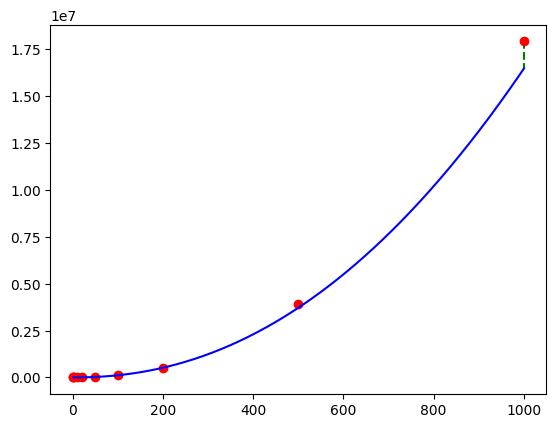

In [23]:
for i, px in np.ndenumerate(n):
    py = t[i]
    pz = T_estimated(px)
    plt.plot((px, px),(py, pz), color="green", linestyle='dashed')
plt.plot(n, t, color="red", marker='o', linestyle='None')
plt.plot(scale, times, color='blue')
#plt.show()
#plt.savefig('1.png')

Як зміниться якість наближення, якщо не розглядати експериментальні дані в малих точках?

## Частину 1 зроблено!